# 1. Introduction

Note:
Netflix is one of the biggest streaming platforms with movies and TV shows from different countries.
In this project we analyze the Netflix dataset to understand trends like popular genres, ratings, actors, and yearly content growth.

Goal of Project

Understand Netflix content distribution

Analyze movies vs TV shows

Identify popular actors, directors, genres

Find trends over years

# 2. Import Libraries

Note:
Libraries help to read data, process data and visualize results.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# 3. Load Dataset

Note:
We load the CSV dataset using pandas.

In [3]:
df = pd.read_csv("netflix_movies.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# 4. Understand Dataset
Shape of Dataset

Note:
Shows number of rows and columns.

In [4]:
df.shape

(8807, 12)

# Columns in Dataset

Note:
Shows all column names.

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

# Dataset Info

Note:
Shows datatype and null values.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


# 5. Missing Values

Note:
Check which columns contain missing data.

In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

# Handling Missing Values:
In the dataset some columns like director, cast, country contain missing values. These missing values are handled using fillna() method by replacing them with suitable values like "Unknown", "Not Available" or most frequent values.

In [8]:
df["director"].fillna("Unknown", inplace=True)
df["cast"].fillna("Not Available", inplace=True)
df["country"].fillna("Unknown", inplace=True)
df["date_added"].fillna(method="ffill", inplace=True)
df["rating"].fillna(df["rating"].mode()[0], inplace=True)
df["duration"].fillna("Unknown", inplace=True)

In [9]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

# 6. Data Cleaning
Convert Date Column

Note:
Convert object to datetime.

In [10]:
df["date_added"] = pd.to_datetime(df["date_added"])
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

# 7. Univariate Analysis
Movies vs TV Shows

Note:
Check which type is more.

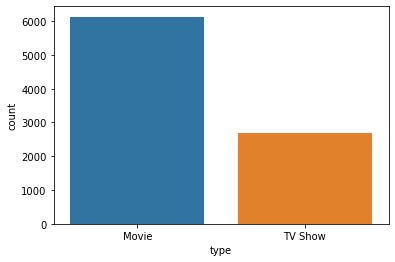

In [11]:
sns.countplot(x="type", data=df)
plt.show()

# Ratings Distribution

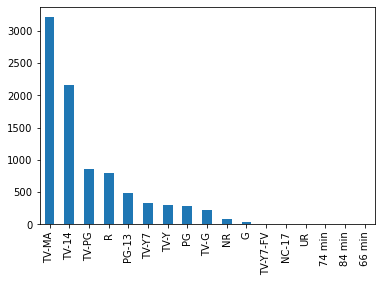

In [12]:
df["rating"].value_counts().plot(kind="bar")
plt.show()

# 8. Bivariate Analysis
Shows Added Per Year

Note:
Understand growth of Netflix content.

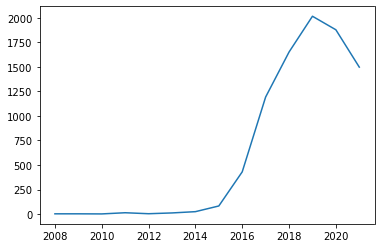

In [13]:
df["year_added"].value_counts().sort_index().plot(kind="line")
plt.show()


# Genre Analysis

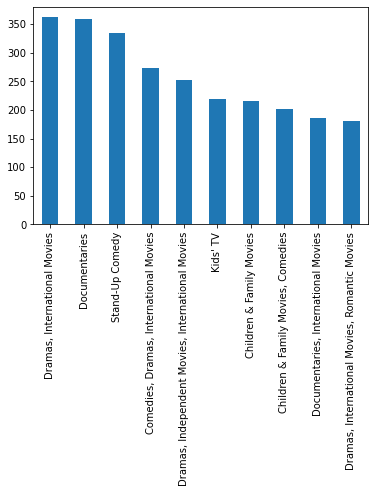

In [14]:
df["listed_in"].value_counts().head(10).plot(kind="bar")
plt.show()

# 9. Actor Analysis
Salman Khan Movies

In [15]:
df[df["cast"].str.contains("Salman", na=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
1441,s1442,Movie,Hello Brother,Sohail Khan,"Salman Khan, Arbaaz Khan, Rani Mukerji, Johny ...",India,2021-01-04,1999,TV-14,126 min,"Action & Adventure, Comedies, International Mo...",After receiving a heart transplant from a murd...,2021,1
1674,s1675,Movie,Bodyguard,Siddique,"Salman Khan, Kareena Kapoor, Raj Babbar, Asran...",India,2020-11-19,2011,TV-14,130 min,"Action & Adventure, Comedies, International Mo...","Irked by her bodyguard, an heiress invents a s...",2020,11
1939,s1940,Movie,Dedh Ishqiya,Abhishek Chaubey,"Naseeruddin Shah, Madhuri Dixit, Arshad Warsi,...",India,2020-09-28,2014,TV-14,146 min,"Comedies, Dramas, International Movies",After failing to win the heart of an aristocra...,2020,9
1942,s1943,Movie,Ishqiya,Abhishek Chaubey,"Naseeruddin Shah, Vidya Balan, Arshad Warsi, S...",India,2020-09-28,2009,TV-14,115 min,"Comedies, International Movies, Romantic Movies",A deceitful woman seduces two of her late husb...,2020,9
2339,s2340,Movie,Prem Ratan Dhan Payo,Sooraj R. Barjatya,"Salman Khan, Sonam Kapoor, Anupam Kher, Neil N...",India,2020-06-25,2015,TV-14,164 min,"Action & Adventure, Dramas, International Movies",While recovering from an assassination attempt...,2020,6
2545,s2546,Movie,Andaz Apna Apna,Rajkumar Santoshi,"Aamir Khan, Salman Khan, Raveena Tandon, Karis...",India,2020-05-11,1994,TV-14,160 min,"Action & Adventure, Comedies, Cult Movies",Broke and with no concrete plans for the futur...,2020,5
2558,s2559,Movie,Si Doel the Movie,Rano Karno,"Rano Karno, Mandra Naih, Cornelia Agatha, Maud...",Indonesia,2020-05-07,2018,TV-PG,86 min,"Dramas, International Movies",Fourteen years after the woman he loved left h...,2020,5
2621,s2622,Movie,Organize Isler,Yılmaz Erdoğan,"Yılmaz Erdoğan, Tolga Çevik, Demet Akbağ, Alta...",Turkey,2020-04-28,2005,TV-14,104 min,"Action & Adventure, Comedies, International Mo...",A gang leader recruits a suicidal Superman imp...,2020,4
2734,s2735,Movie,Kuch Kuch Hota Hai,Karan Johar,"Shah Rukh Khan, Kajol, Rani Mukerji, Farida Ja...",India,2020-04-01,1998,TV-14,185 min,"Comedies, Dramas, International Movies","Per her mother’s last wish, a girl sets out to...",2020,4
2756,s2757,Movie,Paharganj,Rakesh Ranjan Kumar,"Lorena Franco, Bijesh Jayarajan, Neet Chowdhar...",India,2020-03-31,2019,TV-MA,107 min,"Dramas, Independent Movies, International Movies","In the underbelly of a Delhi neighborhood, a w...",2020,3


Shah Rukh Khan Movies

In [16]:
df[df["cast"].str.contains("Shah Rukh", na=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
114,s115,Movie,Anjaam,Rahul Rawail,"Madhuri Dixit, Shah Rukh Khan, Tinnu Anand, Jo...",India,2021-09-02,1994,TV-14,143 min,"Dramas, International Movies, Thrillers",A wealthy industrialist’s dangerous obsession ...,2021,9
301,s302,Movie,Chennai Express,Rohit Shetty,"Shah Rukh Khan, Deepika Padukone, Nikitin Dhee...",India,2021-08-05,2013,TV-14,135 min,"Action & Adventure, Comedies, International Mo...",What could have been a sad journey turns joyfu...,2021,8
2722,s2723,Movie,Duplicate,Mahesh Bhatt,"Shah Rukh Khan, Juhi Chawla, Sonali Bendre, Fa...",India,2020-04-01,1998,TV-14,165 min,"Comedies, Dramas, International Movies",Hilarious mix-ups and deadly encounters ensue ...,2020,4
2730,s2731,Movie,Kabhi Alvida Naa Kehna,Karan Johar,"Amitabh Bachchan, Shah Rukh Khan, Abhishek Bac...",India,2020-04-01,2006,TV-14,192 min,"Dramas, International Movies, Romantic Movies","Unhappy in their respective marriages, an ex-f...",2020,4
2731,s2732,Movie,Kabhi Khushi Kabhie Gham,Karan Johar,"Amitabh Bachchan, Jaya Bhaduri, Shah Rukh Khan...",India,2020-04-01,2001,TV-14,209 min,"Dramas, International Movies",Years after his father disowns his adopted bro...,2020,4
2732,s2733,Movie,Kal Ho Naa Ho,Nikkhil Advani,"Shah Rukh Khan, Saif Ali Khan, Preity Zinta, J...",India,2020-04-01,2003,TV-14,187 min,"Comedies, Dramas, International Movies",An uptight MBA student falls for the charismat...,2020,4
2734,s2735,Movie,Kuch Kuch Hota Hai,Karan Johar,"Shah Rukh Khan, Kajol, Rani Mukerji, Farida Ja...",India,2020-04-01,1998,TV-14,185 min,"Comedies, Dramas, International Movies","Per her mother’s last wish, a girl sets out to...",2020,4
3133,s3134,Movie,Don,Farhan Akhtar,"Shah Rukh Khan, Priyanka Chopra, Arjun Rampal,...",India,2019-12-15,2006,TV-14,169 min,"Action & Adventure, International Movies",A ruthless crime boss and drug lord is nabbed ...,2019,12
3134,s3135,Movie,Don 2,Farhan Akhtar,"Shah Rukh Khan, Priyanka Chopra, Boman Irani, ...","India, Germany",2019-12-15,2011,TV-14,148 min,"Action & Adventure, International Movies, Musi...","With Asia under his complete control, criminal...",2019,12
3376,s3377,Movie,My Next Guest with David Letterman and Shah Ru...,Michael Steed,"Shah Rukh Khan, David Letterman",Unknown,2019-10-25,2019,TV-PG,61 min,International Movies,"""King of Bollywood"" Shah Rukh Khan opens up ab...",2019,10


Akshay Kumar Movies

In [17]:
df[df["cast"].str.contains("Akshay", na=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
118,s119,Movie,Gurgaon,Shanker Raman,"Akshay Oberoi, Pankaj Tripathi, Ragini Khanna,...",India,2021-09-02,2017,TV-14,106 min,"Dramas, International Movies, Thrillers",When the daughter of a wealthy family returns ...,2021,9
209,s210,Movie,Once Upon a Time in Mumbai Dobaara!,Milan Luthria,"Akshay Kumar, Imran Khan, Sonakshi Sinha, Sona...",India,2021-08-27,2013,TV-14,142 min,"Dramas, International Movies, Music & Musicals",This turbulent sequel to Once Upon a Time in M...,2021,8
1122,s1123,Movie,Madam Chief Minister,Subhash Kapoor,"Richa Chadda, Saurabh Shukla, Manav Kaul, Shub...",India,2021-04-01,2020,TV-14,121 min,"Dramas, International Movies",Rising from disadvantage to become a state lea...,2021,4
1305,s1306,Movie,Awara Paagal Deewana,Vikram Bhatt,"Akshay Kumar, Sunil Shetty, Aftab Shivdasani, ...",India,2021-02-16,2002,TV-14,162 min,"Action & Adventure, Comedies, Dramas",A dentist unwittingly becomes caught in the ma...,2021,2
1865,s1866,Movie,Phir Hera Pheri,Neeraj Vora,"Akshay Kumar, Sunil Shetty, Paresh Rawal, Bipa...",India,2020-10-12,2006,TV-14,150 min,"Comedies, International Movies","Driven by greed, three rich friends seek to do...",2020,10
1946,s1947,Movie,Welcome,Anees Bazmee,"Akshay Kumar, Katrina Kaif, Nana Patekar, Anil...",India,2020-09-28,2007,TV-PG,149 min,"Comedies, International Movies, Music & Musicals","In this silly Bollywood farce, the brothers of...",2020,9
2026,s2027,Movie,Poshter Girl,Sameer Patil,"Sonalee Kulkarni, Hrishikesh Joshi, Jitendra J...",India,2020-09-10,2016,TV-14,138 min,"Comedies, Dramas, International Movies","In a town infamous for female infanticide, a y...",2020,9
2268,s2269,Movie,Boss,Anthony D'Souza,"Akshay Kumar, Ronit Roy, Shiv Pandit, Mithun C...",India,2020-07-05,2013,TV-14,139 min,"Action & Adventure, Comedies, Dramas","Disowned by his father as a boy, Surya is take...",2020,7
2273,s2274,Movie,Gabbar Is Back,Krish,"Akshay Kumar, Shruti Haasan, Sunil Grover, Kar...",India,2020-07-05,2015,TV-14,128 min,"Action & Adventure, Dramas, International Movies",After a vengeful college professor targets cor...,2020,7
2281,s2282,Movie,Oh My God,Umesh Shukla,"Akshay Kumar, Paresh Rawal, Mithun Chakraborty...",India,2020-07-05,2012,TV-PG,129 min,"Comedies, Dramas, International Movies",Mumbai shopkeeper Kanji Bhai files a lawsuit a...,2020,7


# 10. Director Analysis
Directors with Most Shows

In [18]:
df["director"].value_counts().head(10)

Unknown                   2634
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Jay Chapman                 12
Youssef Chahine             12
Martin Scorsese             12
Name: director, dtype: int64

# 11. Content Duration Analysis

Note:
Find longest movies or shows.

In [19]:
df["duration"].value_counts().head()

1 Season     1793
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
Name: duration, dtype: int64

# 12. Month-wise Content Release

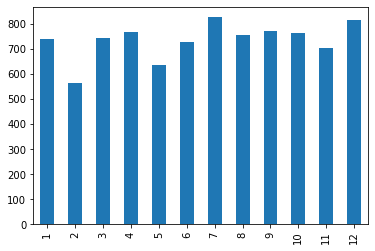

In [20]:
df["month_added"].value_counts().sort_index().plot(kind="bar")
plt.show()

# 13. Insights (Important)

Example insights:

Movies are more than TV Shows on Netflix

Most content added after 2015

Drama and Comedy are the most common genres

Some actors appear frequently in Netflix movies

Certain directors produce more shows

# 14. Conclusion

Note:
From this analysis we understood Netflix content trends including popular genres, actors, and yearly growth. This EDA helps in understanding viewer trends and content strategy.

 Input: Netflix CSV dataset
Process: Data Cleaning → Data Analysis → Visualization
Output: Insights about Netflix movies and TV shows

In this project I cleaned the Netflix dataset, handled missing values, converted date columns, and performed exploratory data analysis to identify trends like popular genres, actors, directors, and year-wise Netflix content growth.